<h1>Derivation of the Binomial Distribution</h1>

Consider a binary experiment characterized by a probability of success $p$ a therefore a probability of failure $q = 1 - p$.

We seek the probability of having $n$ successes in $N$ tries, regardless of the order in which the successes take place.

**Probability of a specific sequence of n successes out of N tries:**

Assume that successive experiments are independent, e.g., one tosses the same coin many times, each time independently of each other. The probability of having $n$ successes and therefore $N - n$ failures occurring in a specific sequence, is given by:

\begin{equation}
  P = p^n \cdot q^{N - n} \tag{1}
\end{equation}

**Number of ordered sequences**

We start by counting how many ordered sequences exist that have $n$ successes out of $N$ tries.

If there are no successes ($n = 0$), then there is only one possible sequence with $N$ failures.

If $n > 0$, each of the $N$ tries can yield the “first” success, and therefore there are $N$ possibilities for what try is the first success.

Continuing on to the “second” success, there are only $N - 1$ possibilities left for what trial will be the second success, and so on.

This leads to the following number of sequences containing $n$ time-ordered successes, that is, sequences for which we keep track of the order in which the successes occurred:

\begin{equation}
  Perm (n, N) = N \cdot (N - 1) \cdot (N - 2) \cdot\cdot (N - n + 1) = \frac{N!}{(N - n)!} \tag{2}
\end{equation}

This is called the number of permutations of n successes out of N tries.

**Number of sequences of n successes out of N tries (regardless of order)**

there are $n!$ ways of ordering $n$ successes among themselves, or $Perm(n, n) = n!$.

Since all $n!$ permutations give rise to the same practical situation of $n$ successes, we need to divide the number of (time- ordered) permutations by $n!$ in order to avoid double-counting of permutations with successes in the same trial number.

It is therefore clear that the number of combinations of $n$ successes out of $N$ trials is:

\begin{equation}
  \frac{Perm (n, N)}{n!} = \frac{N!}{(N - n)! n!} \tag{3}
\end{equation}

We use the probability of each sequence ( 1 ) and multiply it by the number of combinations in ( 3 ) to obtain the overall probability of having $n$ successes in $N$ trials:

\begin{equation}
  P(n) = \frac{N!}{(N - n)! n!} p^n \cdot q^{N - n}  \tag{4}
\end{equation}

Example: p = 0.7, q = 0.3

In [16]:
# Import libraries
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [27]:
# User defined functions
fact = sp.special.factorial
def p_binomial(N, n, p):
    q = 1-p
    P_n =  fact(N) / ( fact(N - n) * fact(n) ) * ( p**n ) * ( q**(N - n) )
    return P_n

In [28]:
# Constants
N_tries = 10
n_successes = np.arange(N_tries+1)
p = 0.7

In [29]:
plt.style.use('_mpl-gallery')
plt.rcParams["figure.figsize"] = (10,3)

# make data:
x = n_sucesses
y = p_binomial(N=N_tries, n=n_successes, p=p)



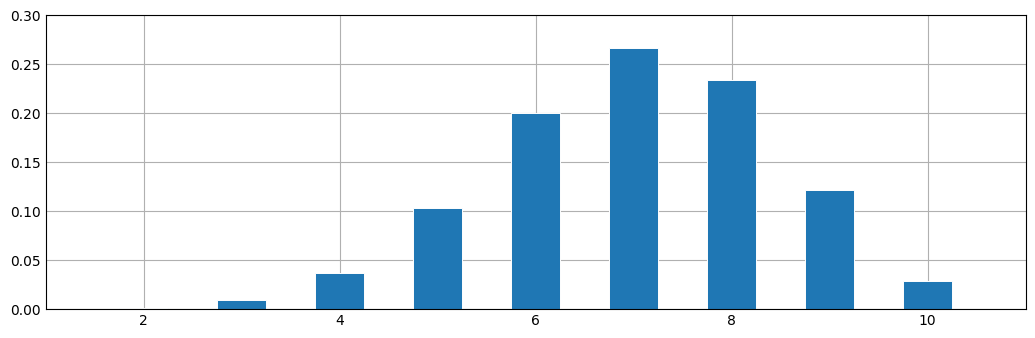

In [30]:
# plot
fig, ax = plt.subplots()

ax.bar(x, y, width=0.5, edgecolor="white", linewidth=0.7)

ax.set(xlim=(1, 11),
       ylim=(0, 0.3))

plt.show()

In [105]:
# Import libraries
import plotly.graph_objects as go
import numpy as np
import scipy as sp

# User defined functions
fact = sp.special.factorial
def p_binomial(N, n, p):
    """
    Eq. 4
    """
    q = 1-p
    P_n =  fact(N) / ( fact(N - n) * fact(n) ) * ( p**n ) * ( q**(N - n) )
    return P_n

# User defined constants
P = np.arange(0.1, 1, 0.1)        # P: array of p [p0, p1, p2 ... pi]
P = np.round(P, 1)        # this line is just to avoid 0.300000... in the plot
Q = 1 - P            # Q: array of q [q1, q2, ... qi]
Q = np.round(Q, 1)        # this line is just to avoid 0.70000... in the plot
N_tries = 10
n_successes = np.arange(1, N_tries+1)    # n_sucesses = [1, 2 ... N_tries]


# Create figure
fig = go.Figure()

# Add traces, one for each slider step
#for p in P:
for p in np.arange(0.1, 1, 0.1):
    fig.add_trace(
        go.Bar(
            visible=False,
            x=n_successes,
            y=p_binomial(N=N_tries, n=n_successes, p=p),
            hovertemplate="p of %%{x} successes<br>out of %s tries<br>= %%{y}<extra></extra>" % N_tries))

# Make 1st trace visible
fig.data[0].visible = True

# Create and add slider
steps = []
for i in range(len(fig.data)):
    step = dict(
        method="update",
        args=[{"visible": [False] * len(fig.data)},
              {"title": f"N = {N_tries}, p = {P[i]}, q = {Q[i]}"}],
        label=str(P[i])
    )
    step["args"][0]["visible"][i] = True  # Toggle i'th trace to "visible"
    steps.append(step)

sliders = [dict(
    active=1,
    currentvalue={"prefix": "probability of success p = "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders
)

fig.show()
